In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
filename = 'PS_2025.11.20_15.22.15.csv'
df = pd.read_csv(filename, comment='#')
df.columns = df.columns.str.strip()
df.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,11 Com b,11 Com,1,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-08,2023-09-19
1,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-05-14,2008-01,2014-05-14
2,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-07-23,2011-08,2014-07-23
3,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2009-10,2014-05-14
4,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-09-04,2017-03,2018-09-06


In [3]:
df_clean = df
df_clean.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,11 Com b,11 Com,1,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-08,2023-09-19
1,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-05-14,2008-01,2014-05-14
2,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-07-23,2011-08,2014-07-23
3,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2009-10,2014-05-14
4,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-09-04,2017-03,2018-09-06


In [4]:
df_clean = df_clean.drop_duplicates(subset=['pl_name'])
df_clean.describe()

,default_flag,sy_snum,sy_pnum,disc_year,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
count,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,5.473000e+03,5.251000e+03,5.251000e+03,5473.000000,3770.00000,...,5799.000000,5753.000000,5749.00000,5748.000000,5758.000000,5721.000000,5721.000000,5714.000000,5714.000000,5714.000000
mean,0.328486,1.104594,1.771315,2016.847819,0.006609,4.721854e+03,1.676982e+03,-1.785596e+03,-0.001279,21.10484,...,-63.580321,12.558233,0.10005,-0.098580,10.408916,0.041577,-0.040096,12.273960,0.000639,-0.000639
std,0.469702,0.345137,1.159948,4.887984,0.081036,1.681705e+05,6.654620e+04,7.587071e+04,0.040535,415.95426,...,272.884863,3.044142,0.19499,0.135585,2.984771,0.257583,0.230813,2.964493,0.001787,0.001787
min,0.000000,1.000000,1.000000,1992.000000,0.000000,9.070629e-02,2.000000e-09,-4.000000e+06,-1.000000,0.00440,...,-2840.000000,0.872000,0.00100,-2.950000,-3.044000,0.011000,-9.995000,2.364310,0.000112,-0.063232
25%,0.000000,1.000000,1.000000,2014.000000,0.000000,4.339460e+00,1.164000e-05,-1.400000e-03,0.000000,0.05850,...,-16.198250,10.670000,0.03000,-0.126000,8.407250,0.020000,-0.031000,10.416800,0.000257,-0.000542
50%,0.000000,1.000000,1.000000,2016.000000,0.000000,1.113179e+01,8.300000e-05,-8.300000e-05,0.000000,0.12540,...,-3.914000,13.270000,0.08000,-0.080000,11.180500,0.023000,-0.023000,13.005650,0.000364,-0.000364
75%,1.000000,1.000000,2.000000,2021.000000,0.000000,4.042883e+01,1.400000e-03,-1.167500e-05,0.000000,0.77000,...,-0.434250,14.952000,0.12600,-0.030000,12.756750,0.031000,-0.020000,14.705225,0.000542,-0.000257
max,1.000000,4.000000,8.000000,2025.000000,1.000000,8.040000e+06,3.650000e+06,-2.000000e-09,1.000000,19000.00000,...,60.000000,32.850000,11.00000,-0.001000,23.930000,9.995000,-0.011000,20.186100,0.063232,-0.000112


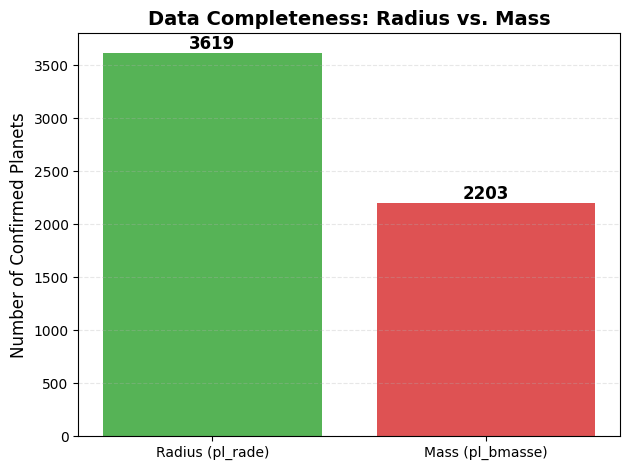

In [5]:
counts = df_clean[['pl_rade', 'pl_bmasse']].count()
counts.index = ['Radius (pl_rade)', 'Mass (pl_bmasse)']
bars = plt.bar(counts.index, counts.values, color=['#2ca02c', '#d62728'], alpha=0.8)
plt.title('Data Completeness: Radius vs. Mass', fontsize=14, fontweight='bold')
plt.ylabel('Number of Confirmed Planets', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('exploratory_1_missing_data.png')
plt.show()

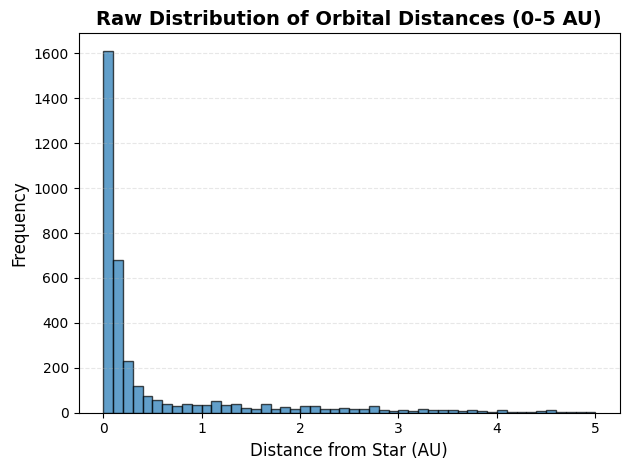

In [6]:
distances = df_clean['pl_orbsmax'].dropna()
plt.hist(distances, bins=50, range=(0, 5), color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Raw Distribution of Orbital Distances (0-5 AU)', fontsize=14, fontweight='bold')
plt.xlabel('Distance from Star (AU)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('exploratory_2_distribution.png')
plt.show()

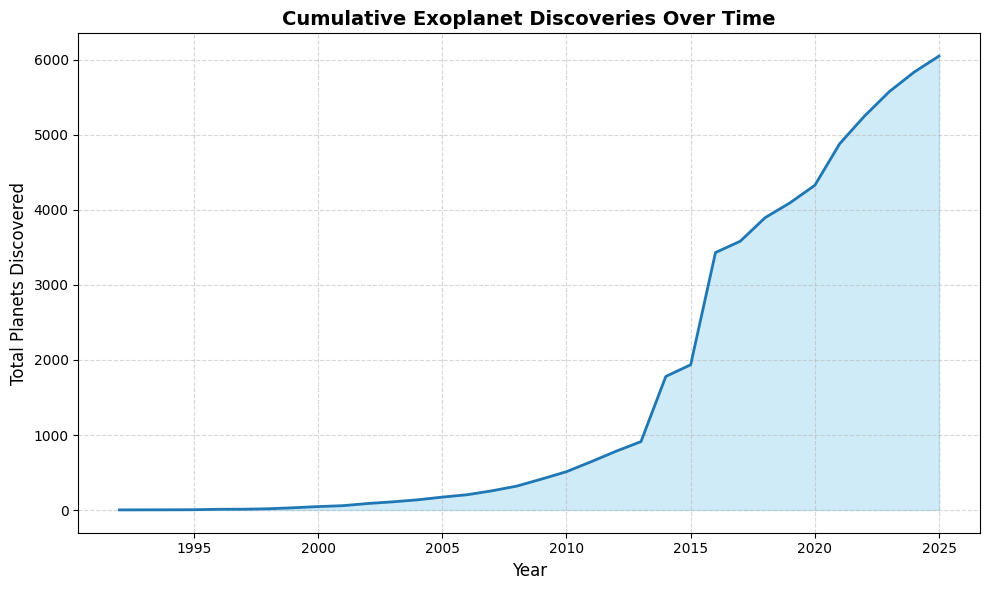

In [7]:
discoveries_per_year = df_clean.groupby('disc_year').size().cumsum()
plt.figure(figsize=(10, 6))
plt.fill_between(discoveries_per_year.index, discoveries_per_year.values, color='skyblue', alpha=0.4)
plt.plot(discoveries_per_year.index, discoveries_per_year.values, color='#1f77b4', linewidth=2)
plt.title('Cumulative Exoplanet Discoveries Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Planets Discovered', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('discoveries_over_time.png')
plt.show()

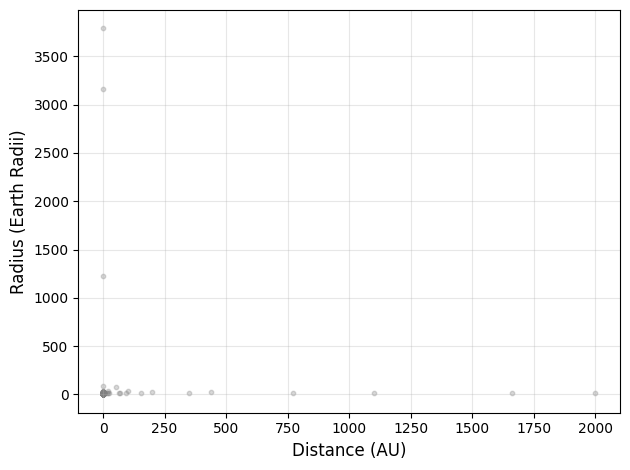

In [8]:
plt.scatter(df_clean['pl_orbsmax'], df_clean['pl_rade'], color='gray', alpha=0.3, s=10)
plt.xlabel('Distance (AU)', fontsize=12)
plt.ylabel('Radius (Earth Radii)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exploratory_linear_fail.png')
plt.show()

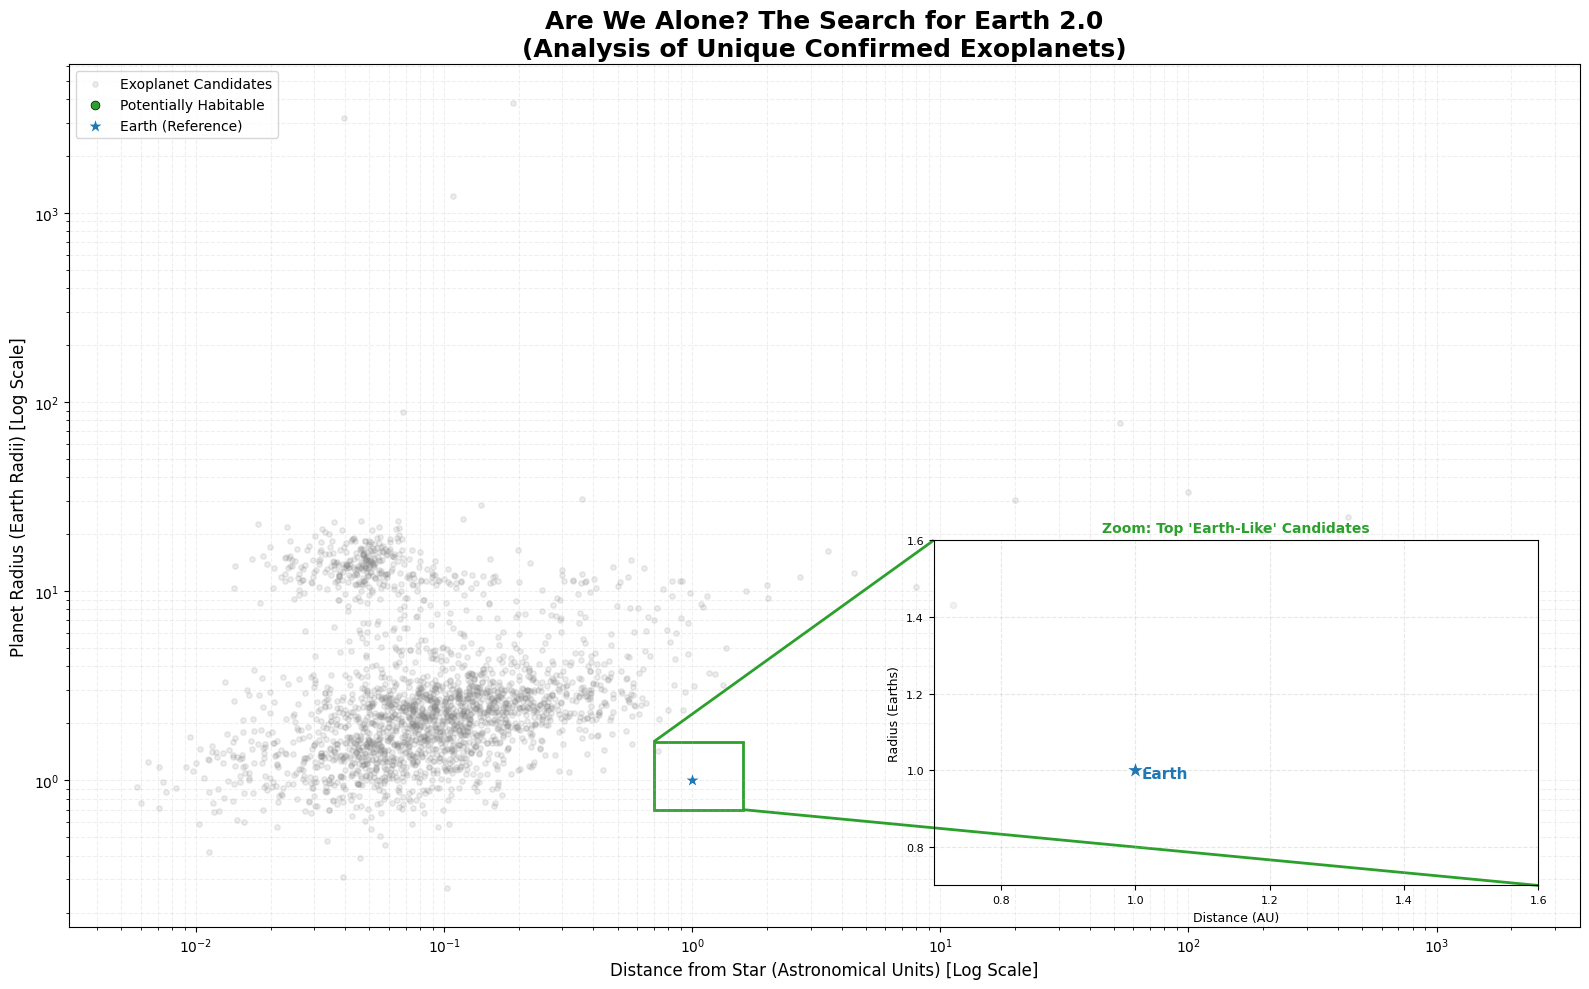

In [10]:
df_habitable = df_clean[
    (df_clean['pl_orbsmax'] >= 0.8) & (df_clean['pl_orbsmax'] <= 1.5) &
    (df_clean['pl_rade'] >= 0.8) & (df_clean['pl_rade'] <= 1.5)
].copy()


df_habitable['earth_dist'] = np.sqrt((df_habitable['pl_orbsmax'] - 1)**2 + (df_habitable['pl_rade'] - 1)**2)
df_habitable = df_habitable.sort_values('earth_dist')


fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(df_clean['pl_orbsmax'], df_clean['pl_rade'], 
           color='gray', alpha=0.15, s=15, label='Exoplanet Candidates')
ax.scatter(df_habitable['pl_orbsmax'], df_habitable['pl_rade'], 
           color='#2ca02c', s=40, edgecolor='black', linewidth=0.5, label='Potentially Habitable')
ax.scatter(1, 1, color='#1f77b4', s=150, edgecolor='white', marker='*', label='Earth (Reference)', zorder=10)

# D. Main Formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Distance from Star (Astronomical Units) [Log Scale]', fontsize=12)
ax.set_ylabel('Planet Radius (Earth Radii) [Log Scale]', fontsize=12)
ax.set_title('Are We Alone? The Search for Earth 2.0\n(Analysis of Unique Confirmed Exoplanets)', fontsize=18, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, which="both", ls="--", alpha=0.2)

axins = inset_axes(ax, width="40%", height="40%", loc='lower right', borderpad=3)

# Plot data inside zoom
axins.scatter(df_clean['pl_orbsmax'], df_clean['pl_rade'], color='gray', alpha=0.1, s=20)
axins.scatter(df_habitable['pl_orbsmax'], df_habitable['pl_rade'], color='#2ca02c', s=80, edgecolor='black', linewidth=0.8)
axins.scatter(1, 1, color='#1f77b4', s=200, edgecolor='white', marker='*', zorder=10)
axins.text(1.01, 0.98, 'Earth', color='#1f77b4', fontweight='bold', fontsize=11)

count = 0
for i, row in df_habitable.iterrows():
    if count < 15:
        axins.text(row['pl_orbsmax'], row['pl_rade']+0.02, row['pl_name'], 
                   fontsize=8, color='#0f5132', ha='center', fontweight='bold')
        count += 1

axins.set_xlim(0.7, 1.6)
axins.set_ylim(0.7, 1.6)

axins.set_title("Zoom: Top 'Earth-Like' Candidates", fontsize=10, color='#2ca02c', fontweight='bold')
axins.grid(True, which="both", ls="--", alpha=0.3)
axins.tick_params(labelsize=8)
axins.set_xlabel('Distance (AU)', fontsize=9)
axins.set_ylabel('Radius (Earths)', fontsize=9)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="#2ca02c", lw=2)

plt.tight_layout()
plt.show()